# **Informe de EDA sobre los jugadores de la FIFA**

En este informe de EDA lo que vamos a analizar son diferentes características sobre el dataset limpio de `players_clean.csv`.

## 1. Carga de librerías y datos

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Para mejorar la estética vamos a utilizar los siguientes comandos.

In [58]:
# Configuración visual moderna
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Y cargamos los datos de players.csv que previamente hemos realizado una limpieza.

In [59]:
# Cargar datos
df = pd.read_csv("../data/clean/players_clean.csv")

Y mostramos el dataset para saber si ha cargado correctamente.

In [60]:
df

,player_id,name,current_club_id,country_of_birth,date_of_birth,position,height_in_cm,contract_expiration_date,current_national_team_id,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav Klose,398,Poland,1978-06-09 00:00:00,Attack,184.0,0,0.0,IT1,Società Sportiva Lazio S.p.A.,1000000,30000000
1,26,Roman Weidenfeller,16,Germany,1980-08-06 00:00:00,Goalkeeper,190.0,0,0.0,L1,Borussia Dortmund,750000,8000000
2,65,Dimitar Berbatov,1091,Bulgaria,1981-01-30 00:00:00,Attack,0.0,0,0.0,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000,34500000
3,77,Lúcio,506,Brazil,1978-05-08 00:00:00,Defender,0.0,0,0.0,IT1,Juventus Football Club,200000,24500000
4,80,Tom Starke,27,East Germany (GDR),1981-03-18 00:00:00,Goalkeeper,194.0,0,0.0,L1,FC Bayern München,100000,3000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
47696,1529719,Eun-seok Ko,21459,0,2005-06-13 00:00:00,Missing,183.0,0,0.0,RSK1,Gangwon Football Club,0,0
47697,1535382,Wojciech Pańkowski,6456,0,2008-07-31 00:00:00,Goalkeeper,190.0,0,0.0,PL1,GKS GieKSa Katowice Spółka Akcyjna,0,0
47698,1545440,Borys Mołdach,3527,0,2009-02-17 00:00:00,Goalkeeper,0.0,0,0.0,PL1,Motor Lublin Spółka Akcyjna,0,0
47699,1545442,Kacper Surowiec,15906,0,2008-09-29 00:00:00,Midfield,0.0,0,0.0,PL1,Termalica Bruk-Bet Nieciecza Klub Sportowy,0,0


## 2. Inspección inicial del conjunto de datos

### Dimensiones

Vamos a analizar las dimensiones de nuestro dataset.

In [61]:
df.shape

(47701, 13)

La conclusion que sacamos de este dataset es la siguiente:

* La `jugadores totales` es: 47701
* La `columnas' del dataset`: 13

### Visualización de las primeras filas

Visualizamos las primeras filas del dataset.

In [62]:
df.head()

,player_id,name,current_club_id,country_of_birth,date_of_birth,position,height_in_cm,contract_expiration_date,current_national_team_id,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav Klose,398,Poland,1978-06-09 00:00:00,Attack,184.0,0,0.0,IT1,Società Sportiva Lazio S.p.A.,1000000,30000000
1,26,Roman Weidenfeller,16,Germany,1980-08-06 00:00:00,Goalkeeper,190.0,0,0.0,L1,Borussia Dortmund,750000,8000000
2,65,Dimitar Berbatov,1091,Bulgaria,1981-01-30 00:00:00,Attack,0.0,0,0.0,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000,34500000
3,77,Lúcio,506,Brazil,1978-05-08 00:00:00,Defender,0.0,0,0.0,IT1,Juventus Football Club,200000,24500000
4,80,Tom Starke,27,East Germany (GDR),1981-03-18 00:00:00,Goalkeeper,194.0,0,0.0,L1,FC Bayern München,100000,3000000


Esto nos permite comprobar:

* Formato de las variables.
* Valores esperados.
* Posibles anomalías.

### Información general

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47701 entries, 0 to 47700
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             47701 non-null  int64  
 1   name                                  47701 non-null  str    
 2   current_club_id                       47701 non-null  int64  
 3   country_of_birth                      47701 non-null  str    
 4   date_of_birth                         47701 non-null  str    
 5   position                              47701 non-null  str    
 6   height_in_cm                          47701 non-null  float64
 7   contract_expiration_date              47701 non-null  str    
 8   current_national_team_id              47701 non-null  float64
 9   current_club_domestic_competition_id  47701 non-null  str    
 10  current_club_name                     47701 non-null  str    
 11  market_value_in_eur       

## 3. Descripción de las variables

Para empezar vamos a separar las variables númericas y categóricas

In [64]:
# Definimos las columnas numéricas y categóricas reales de nuestro archivo limpio
columnas_num = ['height_in_cm', 'market_value_in_eur', 'highest_market_value_in_eur']
columnas_cat = ['country_of_birth', 'position', 'current_club_name', 'current_club_domestic_competition_id']

numericas = df[columnas_num]
categoricas = df[columnas_cat]

### Variables numéricas

In [65]:
numericas.describe()

,height_in_cm,market_value_in_eur,highest_market_value_in_eur
count,47701.000000,4.770100e+04,4.770100e+04
mean,168.069181,1.064828e+06,2.534273e+06
std,48.951019,5.261048e+06,8.353249e+06
min,0.000000,0.000000e+00,0.000000e+00
25%,175.000000,0.000000e+00,0.000000e+00
50%,181.000000,1.000000e+05,2.500000e+05
75%,187.000000,3.500000e+05,1.500000e+06
max,210.000000,2.000000e+08,2.000000e+08


Este análisis nos proporciona la siguiente información:

* Media.
* Desviación estándar.
* Valores mínimos.
* Cuartiles.
* Valores máximos.

Además nos permite identificar:

* Rangos de altura.
* Valor de mercado.
* Internacionalidades.
* Posibles valores extremos.

### Variables categóricas

In [66]:
categoricas.describe()

,country_of_birth,position,current_club_name,current_club_domestic_competition_id
count,47701,47701,47701,47701
unique,203,5,794,33
top,0,Defender,0,TR1
freq,5166,15209,2269,3267


Con este análisis obtenemos:

* Número de valores distintos.
* Moda.
* Frecuencia de la moda.

## 4. Análisis de valores ausentes

Aunque la limpieza haya sido realizada, conviene que documentemos la situación.

In [67]:
df.isnull().sum().sort_values(ascending=False)

player_id                               0
name                                    0
current_club_id                         0
country_of_birth                        0
date_of_birth                           0
position                                0
height_in_cm                            0
contract_expiration_date                0
current_national_team_id                0
current_club_domestic_competition_id    0
current_club_name                       0
market_value_in_eur                     0
highest_market_value_in_eur             0
dtype: int64

Interpretación:

* El dataset limpio muestra 0 valores nulos tradicionales (NaN), lo que confirma que el proceso de limpieza e imputación se ejecutó correctamente.

* Los nulos originales han sido estandarizados usando valores centinela (como '0' o 'Missing'), por lo que ahora el dataset es completamente consistente para modelado o visualización.

## 5. Distribución de variables numéricas

### Altura

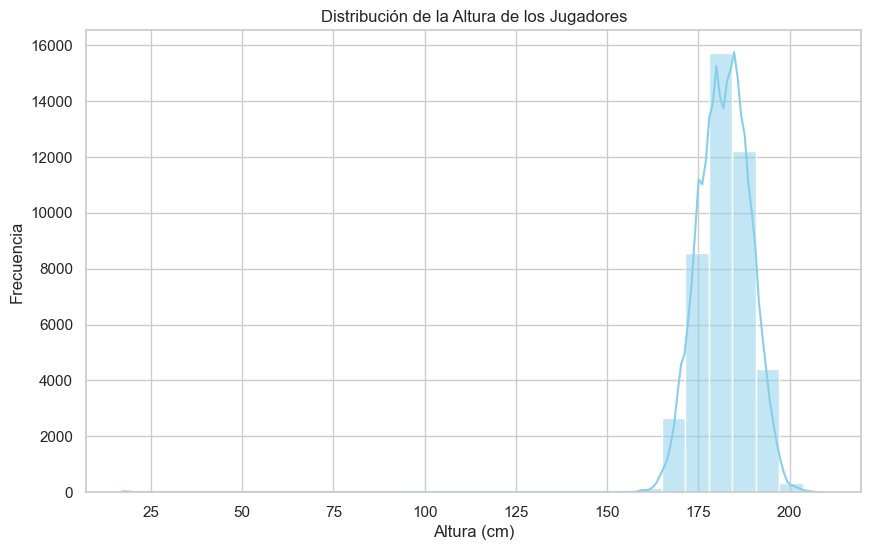

In [79]:
# Filtrar alturas mayores a cero para que el gráfico refleje la distribución real
df_alturas = df[df['height_in_cm'] > 0]

sns.histplot(data=df_alturas, x='height_in_cm', kde=True, bins=30, color='skyblue')
plt.title('Distribución de la Altura de los Jugadores')
plt.xlabel('Altura (cm)')
plt.ylabel('Frecuencia')
plt.show()

Objetivo:

* Detectar la distribución de las alturas.
* Observar posibles outliers.

### Valor de mercado

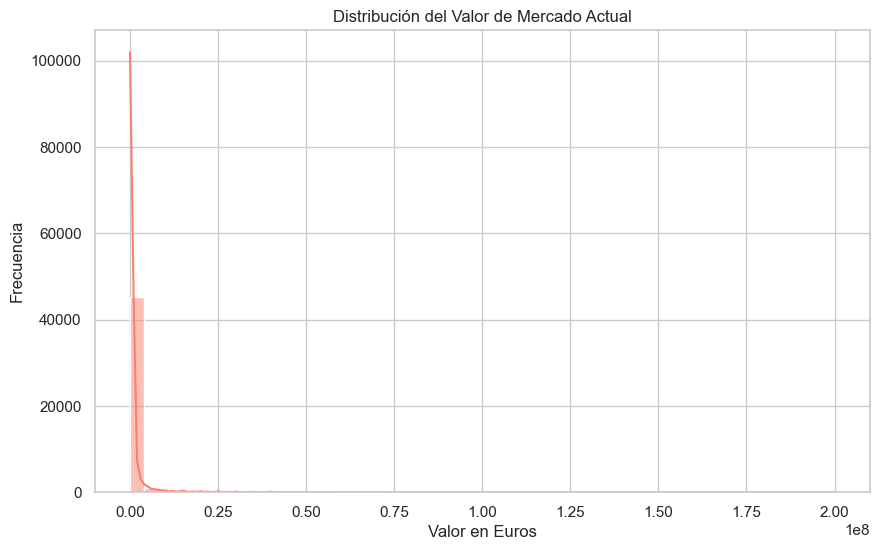

In [69]:
sns.histplot(data=df, x='market_value_in_eur', kde=True, bins=50, color='salmon')
plt.title('Distribución del Valor de Mercado Actual')
plt.xlabel('Valor en Euros')
plt.ylabel('Frecuencia')
plt.show()

Debido a la elevada asimetría:

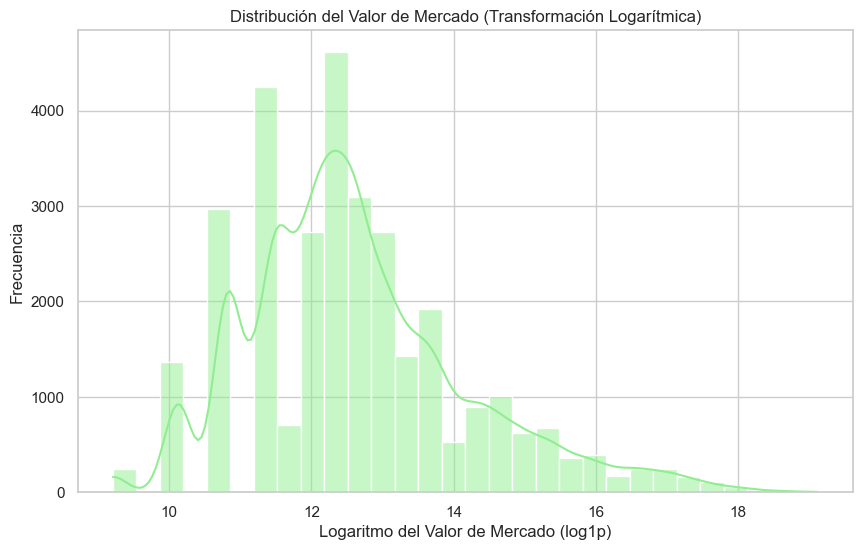

In [81]:
# Filtramos los jugadores con valor mayor a 0 para que los datos ausentes no distorsionen el logaritmo
df_valores = df[df['market_value_in_eur'] > 0]

# Graficamos aplicando la transformación logarítmica
sns.histplot(np.log1p(df_valores['market_value_in_eur']), kde=True, bins=30, color='lightgreen')

# Añadimos títulos y etiquetas claras
plt.title('Distribución del Valor de Mercado (Transformación Logarítmica)')
plt.xlabel('Logaritmo del Valor de Mercado (log1p)')
plt.ylabel('Frecuencia')
plt.show()

Interpretación:

* La mayoría de jugadores tienen valores bajos.
* Un reducido número concentra valores extremadamente elevados.

## 6. Análisis de variables categóricas

### Posición del jugador

In [71]:
df['position'].value_counts()

position
Defender      15209
Midfield      13625
Attack        12885
Goalkeeper     5521
Missing         461
Name: count, dtype: int64

Representación

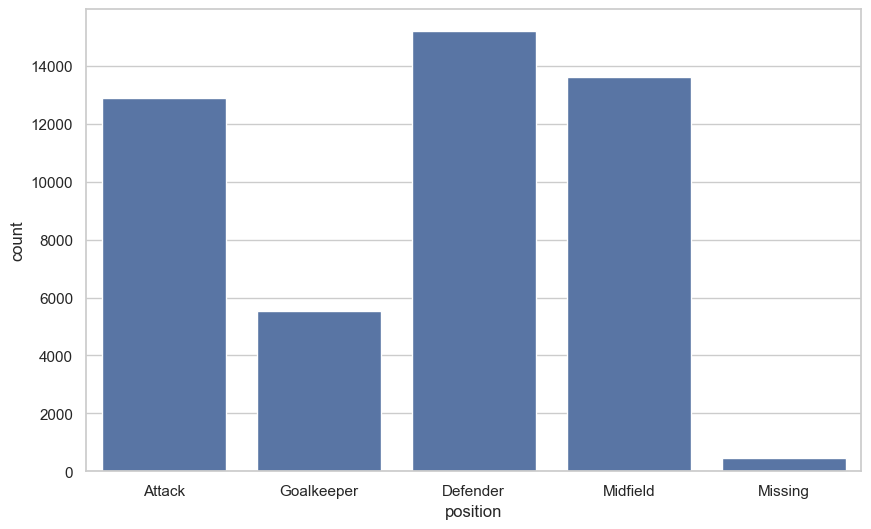

In [72]:
sns.countplot(data=df, x='position')
plt.show()

Permite conocer:

* Defensas.
* Centrocampistas.
* Delanteros.
* Porteros.

## 7. Detección de valores extremos

Para la altura:

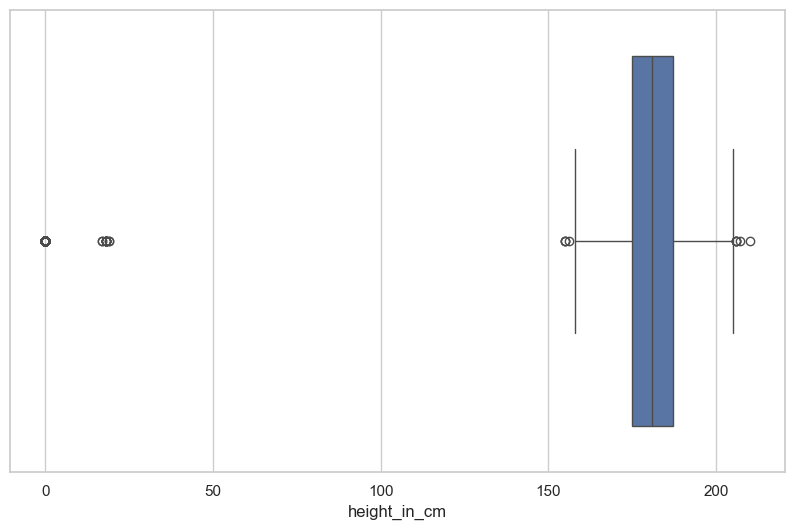

In [73]:
sns.boxplot(x=df['height_in_cm'])
plt.show()

Para el valor de mercado:

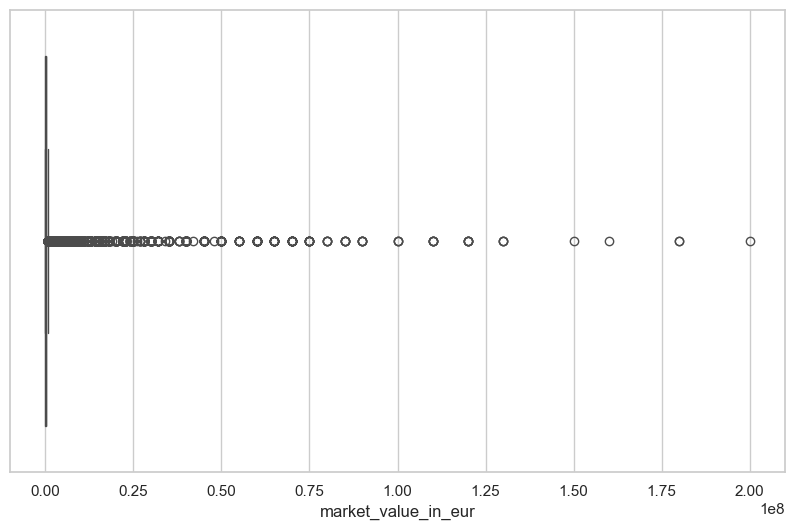

In [74]:
sns.boxplot(x=df['market_value_in_eur'])
plt.show()

Objetivo:

* Identificar observaciones alejadas del comportamiento general.

## 8. Relación entre variables

### Altura según posición

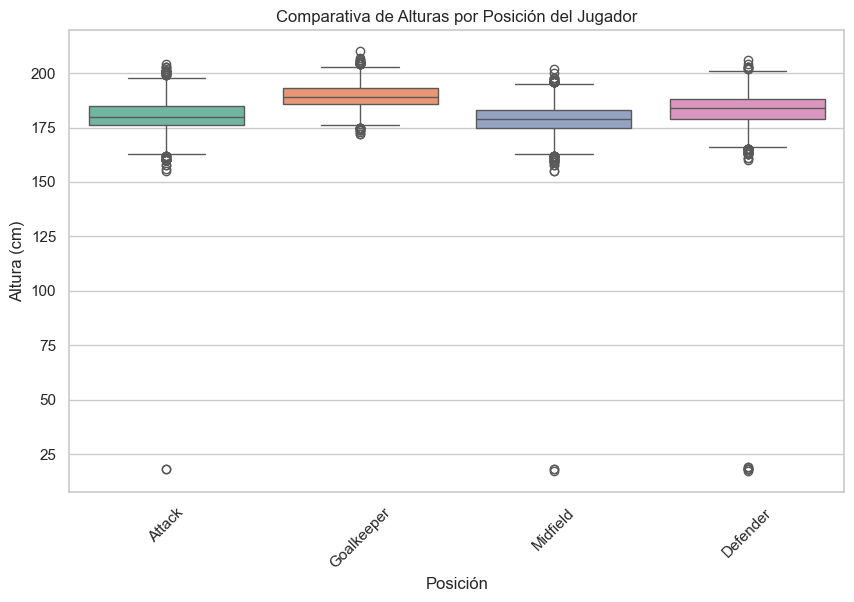

In [84]:
# 1. Filtramos los datos ignorando alturas vacías (0) y posiciones sin registrar
df_pos_alturas = df[(df['height_in_cm'] > 0) & (df['position'] != 'Missing')]

# 2. Creamos el boxplot corrigiendo la sintaxis de palette y hue
sns.boxplot(
    data=df_pos_alturas, 
    x='position', 
    y='height_in_cm', 
    hue='position',     # Asignamos hue a la misma variable X para dar color por grupo
    palette='Set2', 
    legend=False        # Desactivamos la leyenda automática ya que el eje X ya indica la posición
)

# 3. Formato y etiquetas del gráfico
plt.title('Comparativa de Alturas por Posición del Jugador')
plt.xlabel('Posición')
plt.ylabel('Altura (cm)')
plt.xticks(rotation=45)
plt.show()

Permite comprobar:

* Porteros y defensas suelen ser más altos.
* Delanteros y centrocampistas presentan alturas más variadas.

### Valor actual vs valor máximo alcanzado

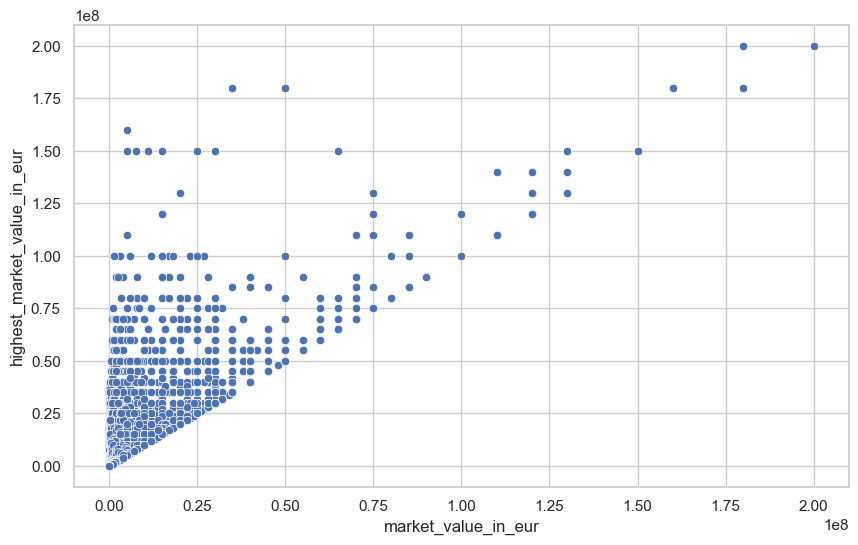

In [76]:
sns.scatterplot(data=df,
                x='market_value_in_eur',
                y='highest_market_value_in_eur')
plt.show()

## 9. Matriz de correlación

Seleccionando las variables numéricas:

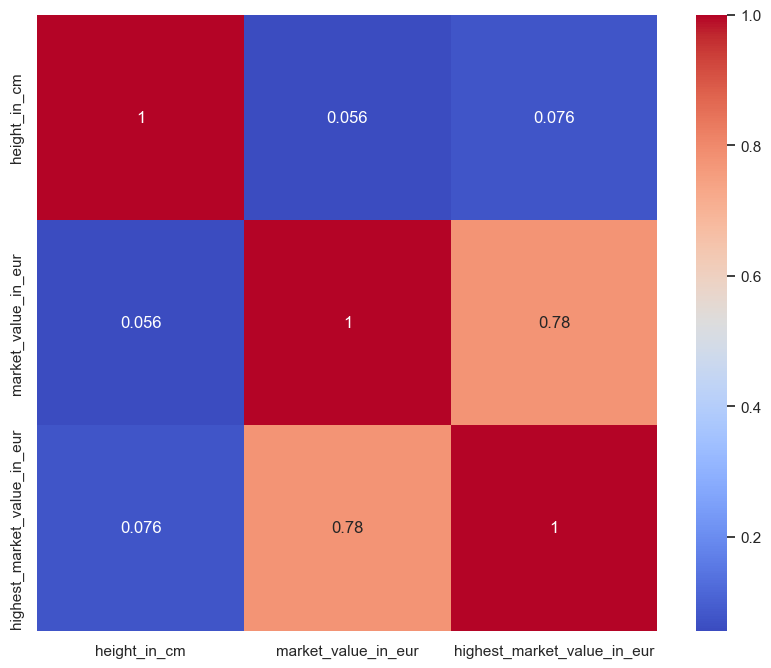

In [77]:
corr = numericas.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.show()

Permite analizar:

* Relaciones lineales entre variables.
* Variables altamente correlacionadas.

## 10. Jugadores con mayor valor de mercado

In [78]:
df[['name','market_value_in_eur']]\
.sort_values(by='market_value_in_eur',
            ascending=False)\
.head(10)

,name,market_value_in_eur
24502,Erling Haaland,200000000
20806,Kylian Mbappé,180000000
22365,Vinicius Junior,180000000
30532,Jude Bellingham,160000000
24077,Phil Foden,150000000
30472,Jamal Musiala,130000000
29926,Michael Olise,130000000
25123,Bukayo Saka,130000000
22196,Federico Valverde,120000000
21254,Alexander Isak,120000000


Esto permite identificar los futbolistas más valiosos del conjunto.

## 11. Conclusiones del EDA

**Estructura del dataset**:

* El conjunto contiene 47.701 jugadores y 13 variables.

* Existe una combinación de variables numéricas y categóricas.

**Calidad de los datos:**

* El conjunto de datos ya se encuentra limpio y estructurado con 47.701 registros y 13 columnas esenciales.

* Los valores ausentes previos han sido estandarizados (los nulos en variables de texto y fechas aparecen controlados como `'0'` o `'Missing'`), evitando fallos en la ejecución del análisis.

**Distribuciones**:

* El valor de mercado presenta una fuerte asimetría.

* La altura muestra una distribución aproximadamente normal.

**Relaciones relevantes:**

* Como era de esperar, existe una correlación lineal positiva muy clara entre el valor actual de un jugador y su valor máximo histórico.

* Al analizar las alturas por posición, se confirma visualmente que los porteros (`Goalkeeper`) y los defensores (`Defender`) tienden a registrar los promedios de altura más altos del dataset.